In [1]:
import src.util as util
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import numpy as np

matplotlib.rcParams['pdf.fonttype'] = 42 
matplotlib.rcParams['font.family'] = 'Helvetica' 

## Road DDO and reddit datasets

In [2]:
data_path = './data/llm-inference-data/'
data_ddo = pd.read_parquet(data_path + 'df_ddo_hf.parquet')
data_reddit = pd.read_parquet(data_path + 'df_reddit_hf.parquet')

In [9]:
data_ddo.head(2)

,user_name,debate_title,debate_texts,party,party_short,debate_category,context,num_token,short_text,num_token_short,party_out_gpt4o,confidence_gpt4o,party_out_llama8b,confidence_llama8b,clean_text
0,0092678,is french horn better than clarinet in intelle...,[\n \n this is my first debate so i dont exp...,Democratic Party,Democratic,Arts,Debate title: is french horn better than clari...,98,Debate title: is french horn better than clari...,98,Democratic,1.0,Republican,1.0,french horn better clarinet intellectual state...
1,0092678,"what makes wings so amazing (buffalo wings, tr...","[\n \n i dissagree, forfeit, \n \n still d...",Democratic Party,Democratic,Miscellaneous,Debate title: what makes wings so amazing (buf...,50,Debate title: what makes wings so amazing (buf...,50,Republican,1.0,Republican,1.0,makes wings amazing buffalo wings traditional ...


In [10]:
data_reddit.head(2)

,user_name,party_short,subreddit,comment_body,num_tokens,inferred_category,party_out_gpt4o,confidence_gpt4o,party_out_llama8b,confidence_llama8b,clean_text
0,-BrutusBuckeye,Republican,AskAChristian,I believe you're thinking of the NAB Do not be...,314,Religion,Republican,4.0,Republican,1.0,believe thinking nab surprised brothers sister...
1,-BrutusBuckeye,Republican,CFB,"What do you mean? Gus ""Jaguar"" Johnson is my d...",701,Sports,Democratic,1.0,Republican,2.0,mean gus jaguar johnson dude im fine hot take ...


## Relation between confidence and inference accruacy 

In [3]:
#f1-scores
f1_conf_list_ddo_gpt, f1_ddo_gpt, f1_errors_ddo_gpt = util.get_f1_over_conf(data_ddo, 
                                            confidence_label='confidence_gpt4o', 
                                            prediction_label='party_out_gpt4o',
                                            true_label='party_short')

f1_conf_list_ddo_llama, f1_ddo_llama, f1_errors_ddo_llama = util.get_f1_over_conf(data_ddo, 
                                            confidence_label='confidence_llama8b', 
                                            prediction_label='party_out_llama8b',
                                            true_label='party_short')

f1_conf_list_reddit_gpt, f1_reddit_gpt, f1_errors_reddit_gpt = util.get_f1_over_conf(data_reddit, 
                                            confidence_label='confidence_gpt4o', 
                                            prediction_label='party_out_gpt4o',
                                            true_label='party_short')

f1_conf_list_reddit_llama, f1_reddit_llama, f1_errors_reddit_llama = util.get_f1_over_conf(data_reddit, 
                                            confidence_label='confidence_llama8b', 
                                            prediction_label='party_out_llama8b',
                                            true_label='party_short')

### Figure 1b, c (confidence vs. F1 score of the text-level inference )

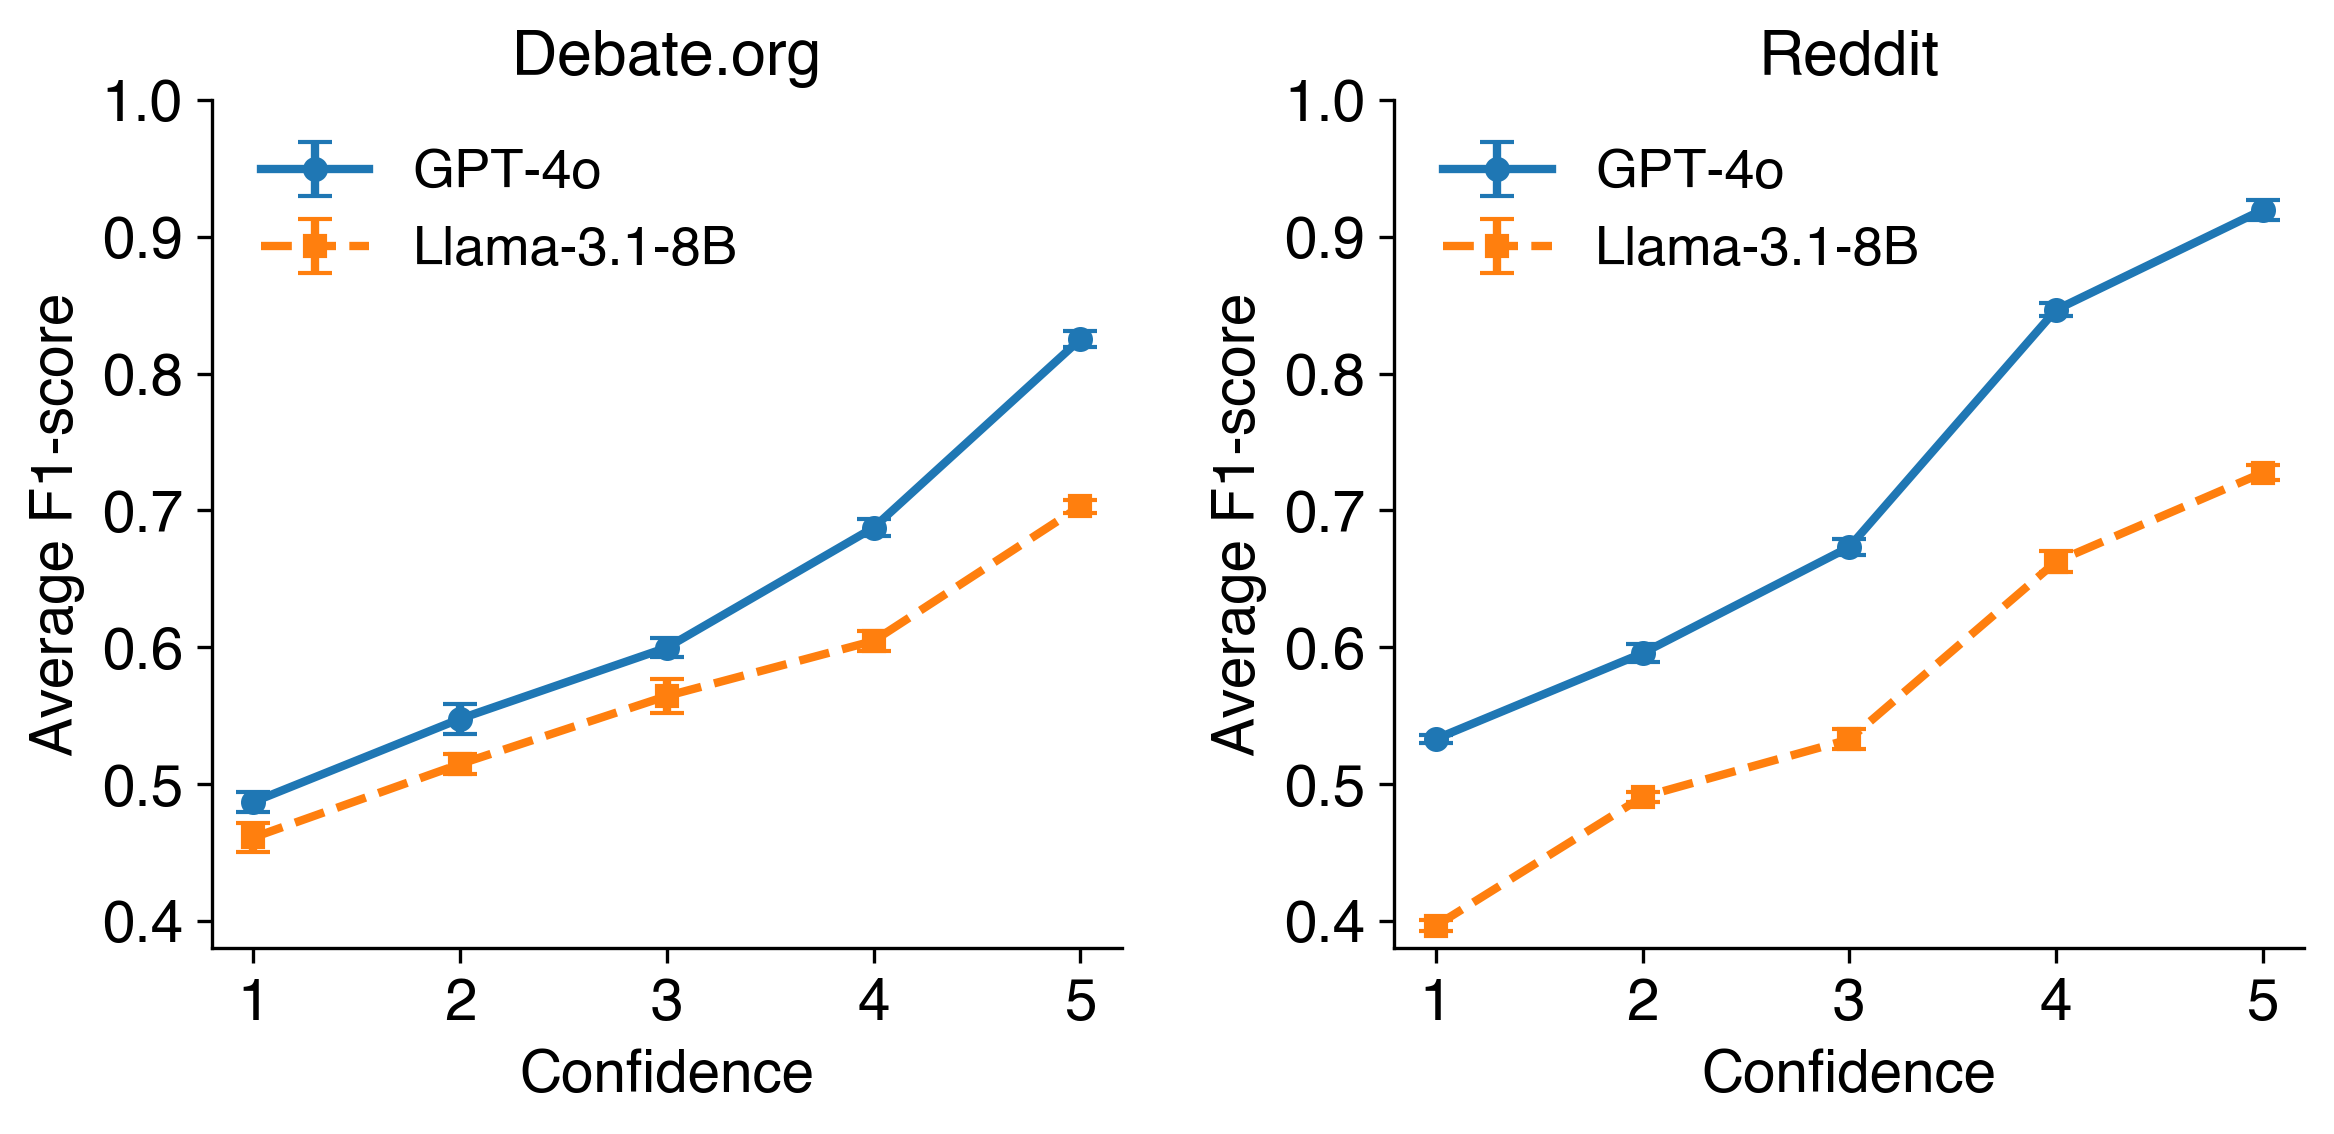

In [8]:
# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# Adjust fonts for readability
plt.rc('font', size=14)  # default text size
plt.rc('axes', titlesize=15, labelsize=14)  # title and axis label sizes

# Plot for Debate.org
axes[0].errorbar(f1_conf_list_ddo_gpt, f1_ddo_gpt, yerr=f1_errors_ddo_gpt, label='GPT-4o', 
                 fmt='o-', linewidth=2, markersize=5, capsize=4)
axes[0].errorbar(f1_conf_list_ddo_llama, f1_ddo_llama, yerr=f1_errors_ddo_llama, label='Llama-3.1-8B',
                 fmt='s--', linewidth=2, markersize=5, capsize=4)
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_title('Debate.org')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Average F1-score')
axes[0].legend(frameon=False, loc=2, fontsize=13)
#axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

# Plot for Reddit
axes[1].errorbar(f1_conf_list_reddit_gpt, f1_reddit_gpt, yerr=f1_errors_reddit_gpt, label='GPT-4o', 
                 fmt='o-', linewidth=2, markersize=5, capsize=4)
axes[1].errorbar(f1_conf_list_reddit_llama, f1_reddit_llama, yerr=f1_errors_reddit_llama, label='Llama-3.1-8B', 
                 fmt='s--', linewidth=2, markersize=5, capsize=4)
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].set_title('Reddit')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Average F1-score')
axes[1].legend(frameon=False, loc=2, fontsize=13)
#axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Clean up the plot (remove top/right spines)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0.38, 1)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
# Show the plot
plt.show()


### Figure 1 d, e (Distributions of confidence)

In [3]:
conf_dist_ddo_gpt = util.get_conf_distribution(data_ddo, 
                                            confidence_label='confidence_gpt4o', 
                                            prediction_label='party_out_gpt4o',
                                            true_label='party_short')

conf_dist_ddo_llama = util.get_conf_distribution(data_ddo, 
                                            confidence_label='confidence_llama8b', 
                                            prediction_label='party_out_llama8b',
                                            true_label='party_short')

conf_dist_reddit_gpt = util.get_conf_distribution(data_reddit, 
                                            confidence_label='confidence_gpt4o', 
                                            prediction_label='party_out_gpt4o',
                                            true_label='party_short')

conf_dist_reddit_llama = util.get_conf_distribution(data_reddit, 
                                            confidence_label='confidence_llama8b', 
                                            prediction_label='party_out_llama8b',
                                            true_label='party_short')

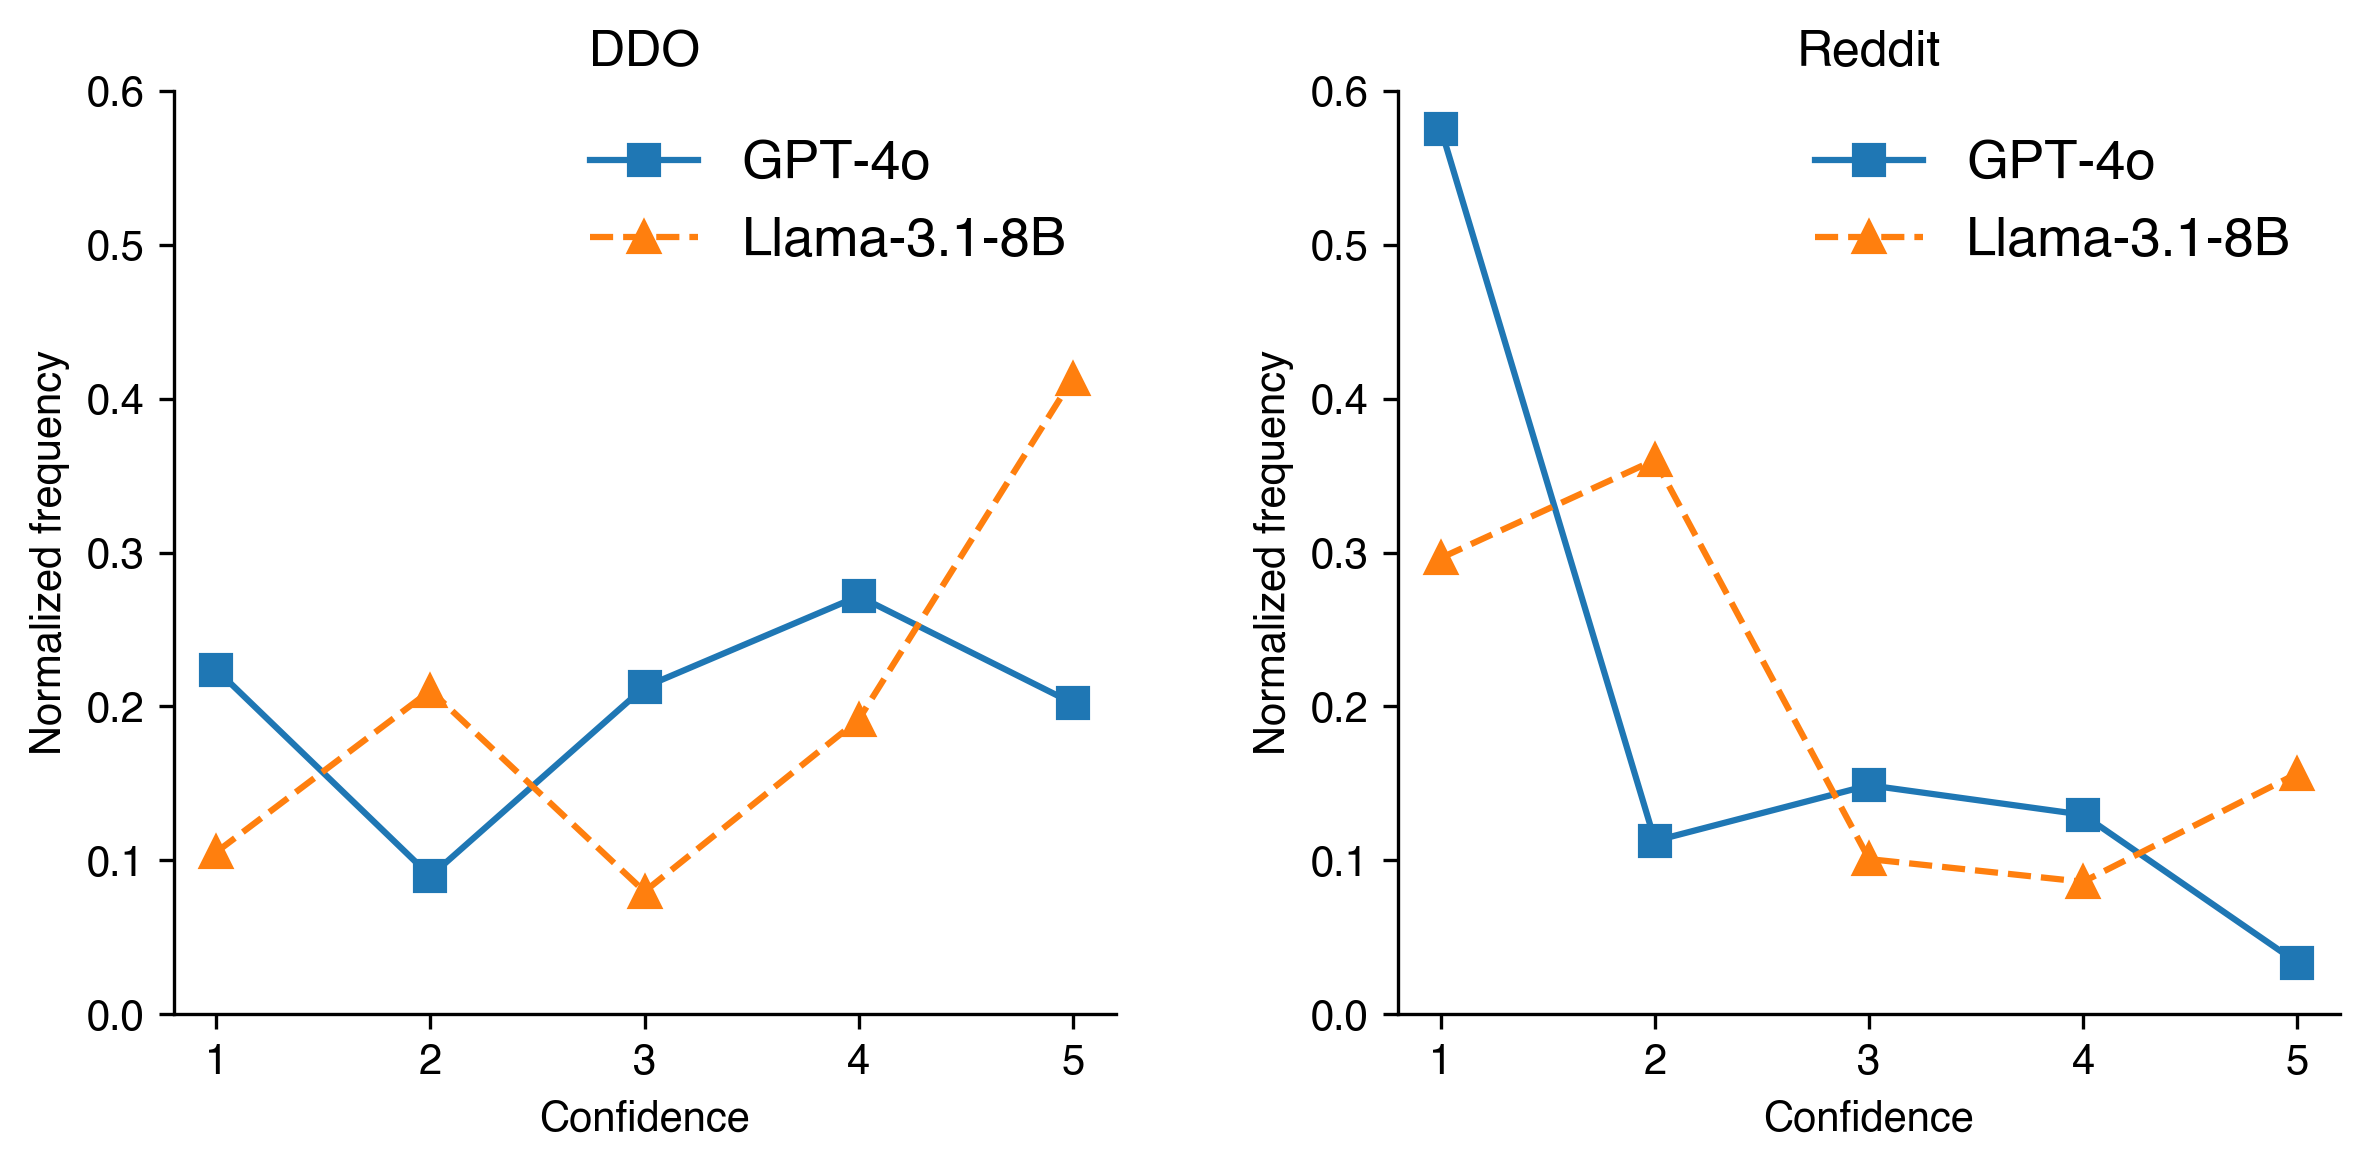

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

axes[0].plot(np.arange(1,6), conf_dist_ddo_gpt, 's-',  ms=7, label='GPT-4o')
axes[0].plot(np.arange(1,6), conf_dist_ddo_llama, '^--',  ms=7, label='Llama-3.1-8B')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_ylim(0,0.6)
axes[0].set_title("DDO")
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Normalized frequency')
axes[0].legend(frameon=False, fontsize=13)


axes[1].plot(np.arange(1,6), conf_dist_reddit_gpt,   's-', ms=7 , label='GPT-4o')
axes[1].plot(np.arange(1,6), conf_dist_reddit_llama, '^--', ms=7 , label='Llama-3.1-8B')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].set_ylim(0,0.6)
axes[1].set_title("Reddit")
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Normalized frequency')
axes[1].legend(frameon=False, fontsize=13)

# Clean up the plot (remove top/right spines)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
# Show the plot
plt.show()

## Calculate text- and user-level inference and compute F1 scores

In [6]:
#example : calculation of text-level, user-level(majority, conf-weighted, max-conf) F1 scores
util.user_level_f1_fourtypes(data_ddo, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')

(0.6465938459097378,
 0.7033612627650411,
 0.7257321380640238,
 0.7237062062741881)

### 1. DDO - GPT-4o

F1 scores based on the inference results of GPT-4o (for Aggregated, Political, and General cases)

In [7]:
def print_three_decimals(values: tuple[float, ...]) -> None:
    formatted = tuple(f"{v:.3f}" for v in values)
    print(formatted)

In [8]:
print("1. Aggregated")
result_ddo_gpt4  = util.user_level_f1_fourtypes(data_ddo, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_ddo_gpt4)

print("2. Political")
data_ddo_pol    = data_ddo[data_ddo['debate_category']=='Politics']
result_ddo_pol_gpt4 = util.user_level_f1_fourtypes(data_ddo_pol, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_ddo_pol_gpt4)

print("3. General")
data_ddo_nonpol = data_ddo[data_ddo['debate_category']!='Politics']
result_ddo_nonpol_gpt4 = util.user_level_f1_fourtypes(data_ddo_nonpol, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_ddo_nonpol_gpt4)

1. Aggregated
('0.647', '0.703', '0.726', '0.724')
2. Political
('0.711', '0.740', '0.754', '0.750')
3. General
('0.619', '0.661', '0.682', '0.685')


### 2. DDO - Llama-3.1-8B

In [9]:
print("1. Aggregated")
result_ddo_llama8b  = util.user_level_f1_fourtypes(data_ddo, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_ddo_llama8b)

print("2. Political")
data_ddo_pol    = data_ddo[data_ddo['debate_category']=='Politics']
result_ddo_pol_llama8b = util.user_level_f1_fourtypes(data_ddo_pol, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_ddo_pol_llama8b)

print("3. General")
data_ddo_nonpol = data_ddo[data_ddo['debate_category']!='Politics']
result_ddo_nonpol_llama8b = util.user_level_f1_fourtypes(data_ddo_nonpol, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_ddo_nonpol_llama8b)

1. Aggregated
('0.619', '0.666', '0.682', '0.695')
2. Political
('0.681', '0.716', '0.725', '0.728')
3. General
('0.595', '0.628', '0.641', '0.647')


### 3. Reddit - GPT-4o

In [10]:
print("1. Aggregated")
result_reddit_gpt4  = util.user_level_f1_fourtypes(data_reddit, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_reddit_gpt4)

print("2. Political")
data_reddit_pol    = data_reddit[data_reddit['inferred_category']=='Politics']
result_reddit_pol_gpt4 = util.user_level_f1_fourtypes(data_reddit_pol, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_reddit_pol_gpt4)

print("3. General")
data_reddit_nonpol = data_reddit[data_reddit['inferred_category']!='Politics']
result_reddit_nonpol_gpt4 = util.user_level_f1_fourtypes(data_reddit_nonpol, prediction_col='party_out_gpt4o', confidence_col='confidence_gpt4o')
print_three_decimals(result_reddit_nonpol_gpt4)

1. Aggregated
('0.624', '0.727', '0.817', '0.839')
2. Political
('0.777', '0.805', '0.821', '0.829')
3. General
('0.606', '0.683', '0.772', '0.799')


### Reddit - Llama-3.1-8B

In [11]:
print("1. Aggregated")
result_reddit_llama8b  = util.user_level_f1_fourtypes(data_reddit, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_reddit_llama8b)

print("2. Political")
data_reddit_pol    = data_reddit[data_reddit['inferred_category']=='Politics']
result_reddit_pol_llama8b = util.user_level_f1_fourtypes(data_reddit_pol, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_reddit_pol_llama8b)

print("3. General")
data_reddit_nonpol = data_reddit[data_reddit['inferred_category']!='Politics']
result_reddit_nonpol_llama8b = util.user_level_f1_fourtypes(data_reddit_nonpol, prediction_col='party_out_llama8b', confidence_col='confidence_llama8b')
print_three_decimals(result_reddit_nonpol_llama8b)

1. Aggregated
('0.534', '0.527', '0.657', '0.763')
2. Political
('0.670', '0.687', '0.723', '0.729')
3. General
('0.520', '0.508', '0.621', '0.723')


### Combine the results to a single dataframe

In [12]:
combined_result = [
    ["Dataset", "Context", "Text-level F1-score", "User-level F1-score", "User-level F1-score (conf-weighted)", "User-level F1-score(max-conf)"],
    ["Debate.org, GPT-4o", "Aggregated"] + list(result_ddo_gpt4),
    ["Debate.org, GPT-4o", "Political"] + list(result_ddo_pol_gpt4),
    ["Debate.org, GPT-4o", "General"] +list(result_ddo_nonpol_gpt4),
    ["Debate.org, Llama-3.1-8B", "Aggregated"] + list(result_ddo_llama8b),
    ["Debate.org, Llama-3.1-8B", "Political"] + list(result_ddo_pol_llama8b),
    ["Debate.org, Llama-3.1-8B", "General"] + list(result_ddo_nonpol_llama8b),
    ["Reddit, GPT-4o", "Aggregated"] + list(result_reddit_gpt4),
    ["Reddit, GPT-4o", "Political"] + list(result_reddit_pol_gpt4),
    ["Reddit, GPT-4o", "General"] + list(result_reddit_nonpol_gpt4),
    ["Reddit, Llama-3.1-8B", "Aggregated"] + list(result_reddit_llama8b),
    ["Reddit, Llama-3.1-8B", "Political"] + list(result_reddit_pol_llama8b),
    ["Reddit, Llama-3.1-8B", "General"] + list(result_reddit_nonpol_llama8b)
]

df = pd.DataFrame(combined_result[1:], columns=combined_result[0])

In [13]:
df

,Dataset,Context,Text-level F1-score,User-level F1-score,User-level F1-score (conf-weighted),User-level F1-score(max-conf)
0,"Debate.org, GPT-4o",Aggregated,0.646594,0.703361,0.725732,0.723706
1,"Debate.org, GPT-4o",Political,0.710674,0.739892,0.754039,0.750291
2,"Debate.org, GPT-4o",General,0.619338,0.661394,0.681726,0.684931
3,"Debate.org, Llama-3.1-8B",Aggregated,0.618798,0.665568,0.682119,0.695061
4,"Debate.org, Llama-3.1-8B",Political,0.681048,0.716321,0.725414,0.728212
5,"Debate.org, Llama-3.1-8B",General,0.595056,0.628278,0.640918,0.646849
6,"Reddit, GPT-4o",Aggregated,0.623756,0.727126,0.817279,0.839043
7,"Reddit, GPT-4o",Political,0.776697,0.805464,0.821085,0.829228
8,"Reddit, GPT-4o",General,0.605747,0.683266,0.771702,0.798664
9,"Reddit, Llama-3.1-8B",Aggregated,0.533903,0.526507,0.656585,0.763373


### Figure 1f-i (text-level and user-level F1-scores across datasets and text types)

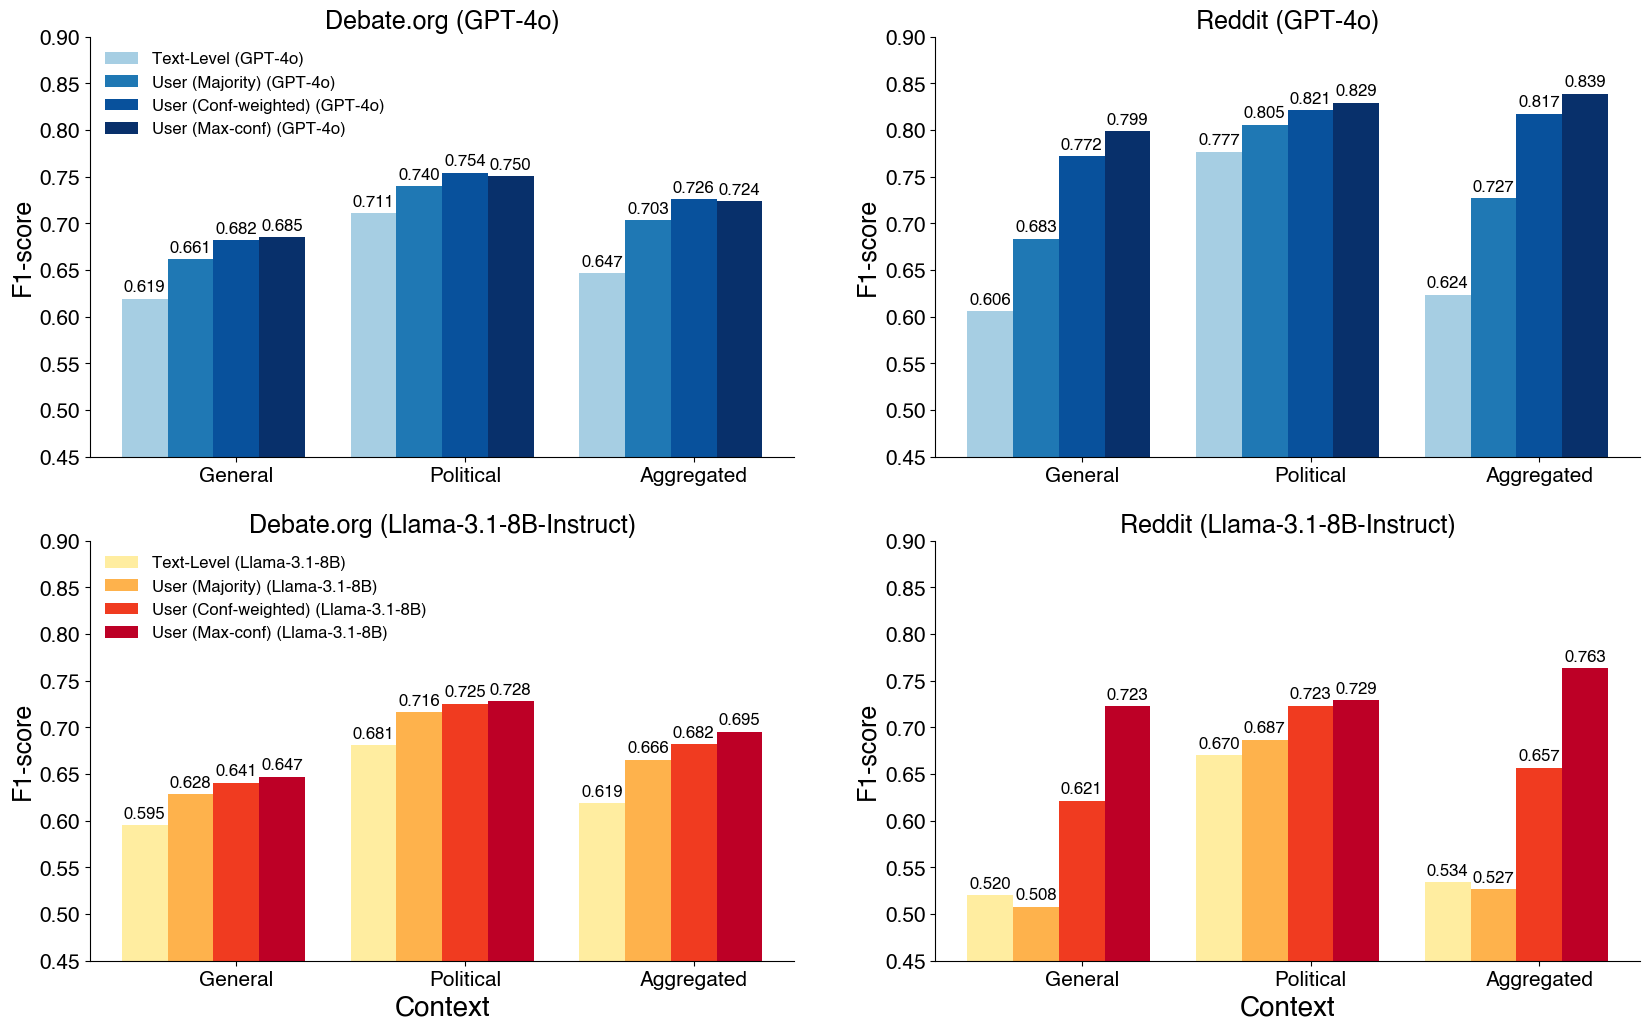

In [14]:
plt.rcParams.update({'font.size': 15})

# generate 2x2 subplots 
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# set width of each bar  
bar_width = 0.2
colors_gpt4o = ['#a6cee3', '#1f78b4', '#08519c', '#08306b'] 
colors_llama = ['#ffeda0', '#feb24c', '#f03b20', '#bd0026']  

# Debate.org data
debate_org_df = df[df['Dataset'].str.contains("Debate.org")]
contexts = ['General', 'Political', 'Aggregated']
debate_org_df = debate_org_df.set_index('Context').loc[contexts].reset_index()

x = np.arange(len(contexts))

# Reddit data
reddit_df = df[df['Dataset'].str.contains("Reddit")]
reddit_df = reddit_df.set_index('Context').loc[contexts].reset_index()

# ploting bar graphs 
# GPT-4o - Debate.org
axes[0, 0].bar(x - 2 * bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, GPT-4o"]['Text-level F1-score'], 
               width=bar_width, color=colors_gpt4o[0], label='Text-Level (GPT-4o)')
axes[0, 0].bar(x - bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, GPT-4o"]['User-level F1-score'], 
               width=bar_width, color=colors_gpt4o[1], label='User (Majority) (GPT-4o)')
axes[0, 0].bar(x, debate_org_df[debate_org_df['Dataset'] == "Debate.org, GPT-4o"]['User-level F1-score (conf-weighted)'], 
               width=bar_width, color=colors_gpt4o[2], label='User (Conf-weighted) (GPT-4o)')
axes[0, 0].bar(x + bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, GPT-4o"]['User-level F1-score(max-conf)'], 
               width=bar_width, color=colors_gpt4o[3], label='User (Max-conf) (GPT-4o)')

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(contexts, fontsize=15)
axes[0, 0].set_title('Debate.org (GPT-4o)', fontsize=18, fontweight='bold')
axes[0, 0].set_ylabel('F1-score', fontsize=18)
axes[0, 0].legend(loc=2, fontsize=12, frameon=False)  # legend 

# GPT-4o - Reddit
axes[0, 1].bar(x - 2 * bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, GPT-4o"]['Text-level F1-score'], 
               width=bar_width, color=colors_gpt4o[0], label='Text-Level (GPT-4o)')
axes[0, 1].bar(x - bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, GPT-4o"]['User-level F1-score'], 
               width=bar_width, color=colors_gpt4o[1], label='User (Majority) (GPT-4o)')
axes[0, 1].bar(x, reddit_df[reddit_df['Dataset'] == "Reddit, GPT-4o"]['User-level F1-score (conf-weighted)'], 
               width=bar_width, color=colors_gpt4o[2], label='User (Conf-weighted) (GPT-4o)')
axes[0, 1].bar(x + bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, GPT-4o"]['User-level F1-score(max-conf)'], 
               width=bar_width, color=colors_gpt4o[3], label='User (Max-conf) (GPT-4o)')

axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(contexts, fontsize=15)
axes[0, 1].set_title('Reddit (GPT-4o)', fontsize=18, fontweight='bold')
axes[0, 1].set_ylabel('F1-score', fontsize=18)


# Llama-3.2-8B - Debate.org
axes[1, 0].bar(x - 2 * bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, Llama-3.1-8B"]['Text-level F1-score'], 
               width=bar_width, color=colors_llama[0], label='Text-Level (Llama-3.1-8B)')
axes[1, 0].bar(x - bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, Llama-3.1-8B"]['User-level F1-score'], 
               width=bar_width, color=colors_llama[1], label='User (Majority) (Llama-3.1-8B)')
axes[1, 0].bar(x, debate_org_df[debate_org_df['Dataset'] == "Debate.org, Llama-3.1-8B"]['User-level F1-score (conf-weighted)'], 
               width=bar_width, color=colors_llama[2], label='User (Conf-weighted) (Llama-3.1-8B)')
axes[1, 0].bar(x + bar_width, debate_org_df[debate_org_df['Dataset'] == "Debate.org, Llama-3.1-8B"]['User-level F1-score(max-conf)'], 
               width=bar_width, color=colors_llama[3], label='User (Max-conf) (Llama-3.1-8B)')

axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(contexts, fontsize=15)
axes[1, 0].set_title('Debate.org (Llama-3.1-8B-Instruct)', fontsize=18, fontweight='bold')
axes[1, 0].set_ylabel('F1-score', fontsize=18)
axes[1, 0].set_xlabel('Context', fontsize=20)
axes[1, 0].legend(loc=2, fontsize=12, frameon=False)  # legend

# Llama-3.2-3B - Reddit
axes[1, 1].bar(x - 2 * bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, Llama-3.1-8B"]['Text-level F1-score'], 
               width=bar_width, color=colors_llama[0], label='Text-Level (Llama-3.1-8B)')
axes[1, 1].bar(x - bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, Llama-3.1-8B"]['User-level F1-score'], 
               width=bar_width, color=colors_llama[1], label='User (Majority) (Llama-3.1-8B)')
axes[1, 1].bar(x, reddit_df[reddit_df['Dataset'] == "Reddit, Llama-3.1-8B"]['User-level F1-score (conf-weighted)'], 
               width=bar_width, color=colors_llama[2], label='User (Conf-weighted) (Llama-3.1-8B)')
axes[1, 1].bar(x + bar_width, reddit_df[reddit_df['Dataset'] == "Reddit, Llama-3.1-8B"]['User-level F1-score(max-conf)'], 
               width=bar_width, color=colors_llama[3], label='User (Max-conf) (Llama-3.1-8B)')

axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(contexts, fontsize=15)
axes[1, 1].set_title('Reddit (Llama-3.1-8B-Instruct)', fontsize=18, fontweight='bold')
axes[1, 1].set_ylabel('F1-score', fontsize=18)
axes[1, 1].set_xlabel('Context', fontsize=20)

for i in range(2):
    for j in range(2):
        ax = axes[i,j]
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        #ax.grid(True, which='major', axis='y',linestyle='--', linewidth=0.5)
        ax.set_ylim(0.45,0.9)
        
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', fontsize=12, padding=3)

plt.show()
